# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan


- Nama: Defangga Aby Vonega
- Email: onecircle.24@gmail.com
- Id Dicoding: defanggaabypn


## Business Understanding

Jaya Jaya Institut merupakan institusi pendidikan yang telah berdiri sejak tahun 2000. Dengan reputasi yang baik dalam mencetak lulusan berkualitas, institusi ini menghadapi masalah serius berupa tingginya angka dropout mahasiswa. Dari total 4.424 mahasiswa dalam dataset, terdapat 1.421 mahasiswa (32.1%) yang berstatus dropout. Angka ini cukup tinggi dan berpotensi merusak reputasi serta keberlanjutan finansial institusi.

Deteksi dini terhadap mahasiswa yang berpotensi dropout sangat penting agar pihak institusi dapat memberikan intervensi dan bimbingan khusus sebelum mahasiswa benar-benar meninggalkan studi mereka.


### Permasalahan Bisnis

1. Tingginya angka dropout mahasiswa (32.1% dari total mahasiswa) yang berdampak pada reputasi dan pendapatan institusi.
2. Belum adanya sistem deteksi dini untuk mengidentifikasi mahasiswa yang berisiko dropout.
3. Tidak adanya dashboard monitoring yang memudahkan pihak institusi dalam memahami pola dan faktor penyebab dropout.
4. Belum optimalnya alokasi sumber daya untuk program bimbingan dan retensi mahasiswa.


### Cakupan Proyek

1. Analisis eksplorasi data untuk memahami karakteristik dan pola dropout mahasiswa.
2. Pembangunan model machine learning untuk memprediksi status mahasiswa (Dropout vs Graduate).
3. Pembuatan dashboard interaktif untuk monitoring performa mahasiswa.
4. Deployment prototype sistem prediksi menggunakan Streamlit.


### Persiapan

Sumber data: [Students' Performance Dataset](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/data.csv)

Setup environment:
```bash
pip install pandas numpy scikit-learn matplotlib seaborn joblib streamlit
```


## Menyiapkan Library dan Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 40)
plt.style.use('seaborn-v0_8-whitegrid')

### Memuat Dataset


In [ ]:
df = pd.read_csv('data.csv', sep=';')
df.columns = [c.replace('\ufeff', '') for c in df.columns]
print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dimensi dataset: 4424 baris, 37 kolom


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding


### Informasi Umum Dataset


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [ ]:
df.describe().round(2)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,10.96,11.03,126.98,0.55,0.01,0.11,0.88,0.35,0.25,23.27,0.02,0.71,6.27,8.30,4.71,10.64,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,26.42,25.26,14.48,0.50,0.11,0.32,0.32,0.48,0.43,7.59,0.16,2.36,2.48,4.18,3.09,4.84,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,0.00,0.00,95.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,4.00,4.00,117.90,0.00,0.00,0.00,1.00,0.00,0.00,19.00,0.00,0.00,5.00,6.00,3.00,11.00,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,5.00,7.00,126.10,1.00,0.00,0.00,1.00,0.00,0.00,20.00,0.00,0.00,6.00,8.00,5.00,12.29,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,9.00,9.00,134.80,1.00,0.00,0.00,1.00,1.00,0.00,25.00,0.00,0.00,7.00,10.00,6.00,13.40,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,194.00,195.00,190.00,1.00,1.00,1.00,1.00,1.00,1.00,70.00,1.00,20.00,26.00,45.00,26.00,18.88,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


### Pengecekan Missing Values dan Duplikat


In [ ]:
print("Missing values per kolom:")
print(df.isnull().sum().to_string())
print(f"\nTotal baris duplikat: {df.duplicated().sum()}")

Missing values per kolom:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment       

### Distribusi Target (Status Mahasiswa)


Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.9
Dropout     32.1
Enrolled    17.9 %


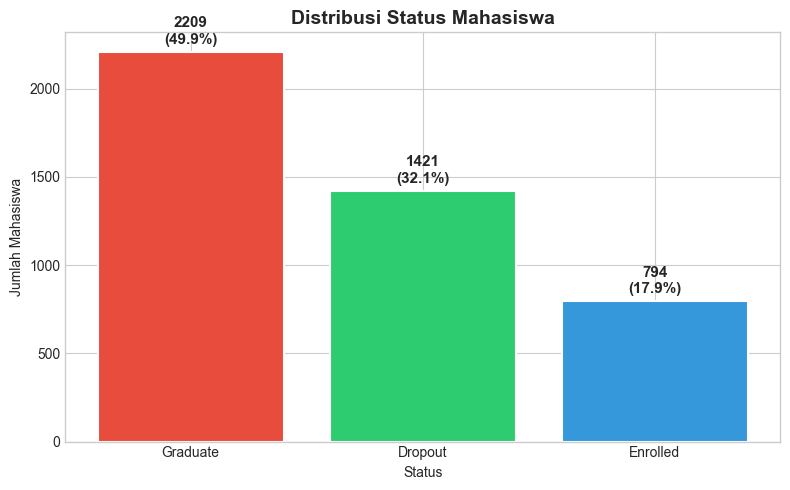

In [ ]:
status_counts = df['Status'].value_counts()
print(status_counts)
print(f"\nPersentase:")
print((status_counts / len(df) * 100).round(1).to_string() + ' %')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax.bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, status_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Mahasiswa')
ax.set_xlabel('Status')
plt.tight_layout()
plt.show()

### Exploratory Data Analysis

Pada tahap ini dilakukan analisis visual terhadap faktor-faktor yang mempengaruhi status mahasiswa.


#### Performa Akademik: Mata Kuliah yang Disetujui per Semester


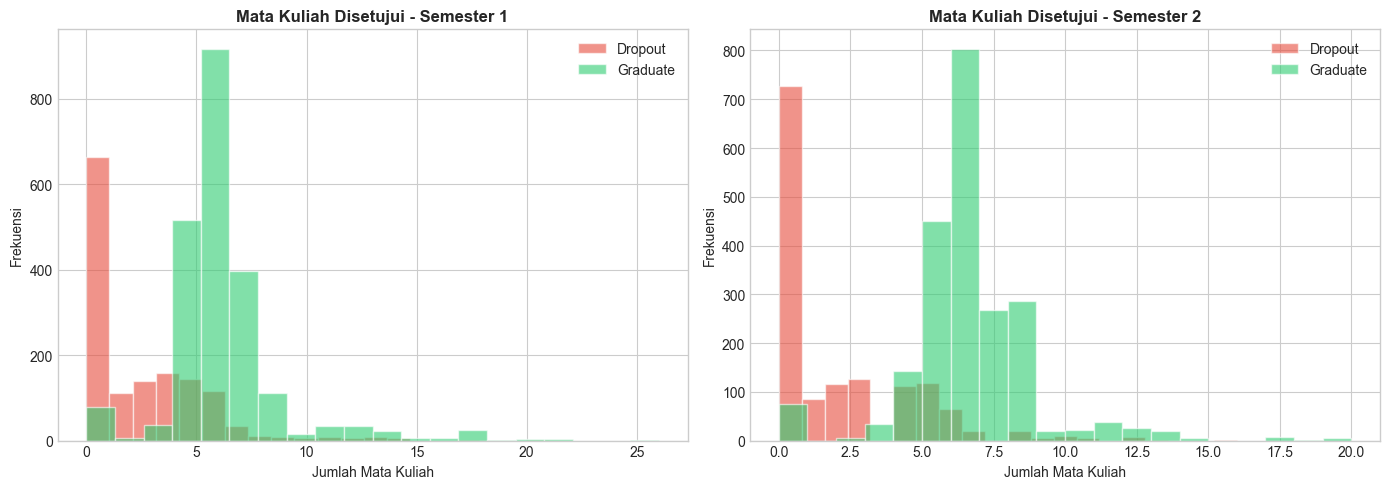

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, sem in enumerate(['1st', '2nd']):
    col = f'Curricular_units_{sem}_sem_approved'
    for status, color in zip(['Dropout', 'Graduate'], ['#e74c3c', '#2ecc71']):
        subset = df[df['Status'] == status]
        axes[i].hist(subset[col], bins=20, alpha=0.6, label=status, color=color, edgecolor='white')
    axes[i].set_title(f'Mata Kuliah Disetujui - Semester {i+1}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Jumlah Mata Kuliah')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Rata-rata Nilai per Semester berdasarkan Status


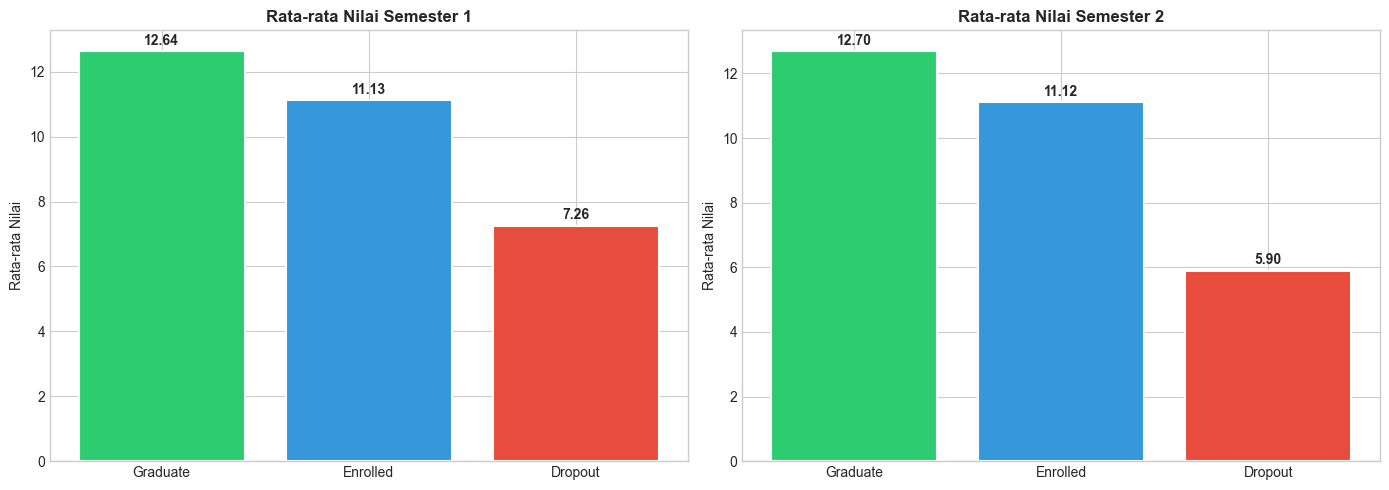

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, sem in enumerate(['1st', '2nd']):
    col = f'Curricular_units_{sem}_sem_grade'
    grade_by_status = df.groupby('Status')[col].mean().sort_values(ascending=False)
    colors_map = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#3498db'}
    bar_colors = [colors_map[s] for s in grade_by_status.index]
    bars = axes[i].bar(grade_by_status.index, grade_by_status.values, color=bar_colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, grade_by_status.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[i].set_title(f'Rata-rata Nilai Semester {i+1}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Rata-rata Nilai')

plt.tight_layout()
plt.show()

#### Dropout Rate berdasarkan Status Pembayaran dan Beasiswa


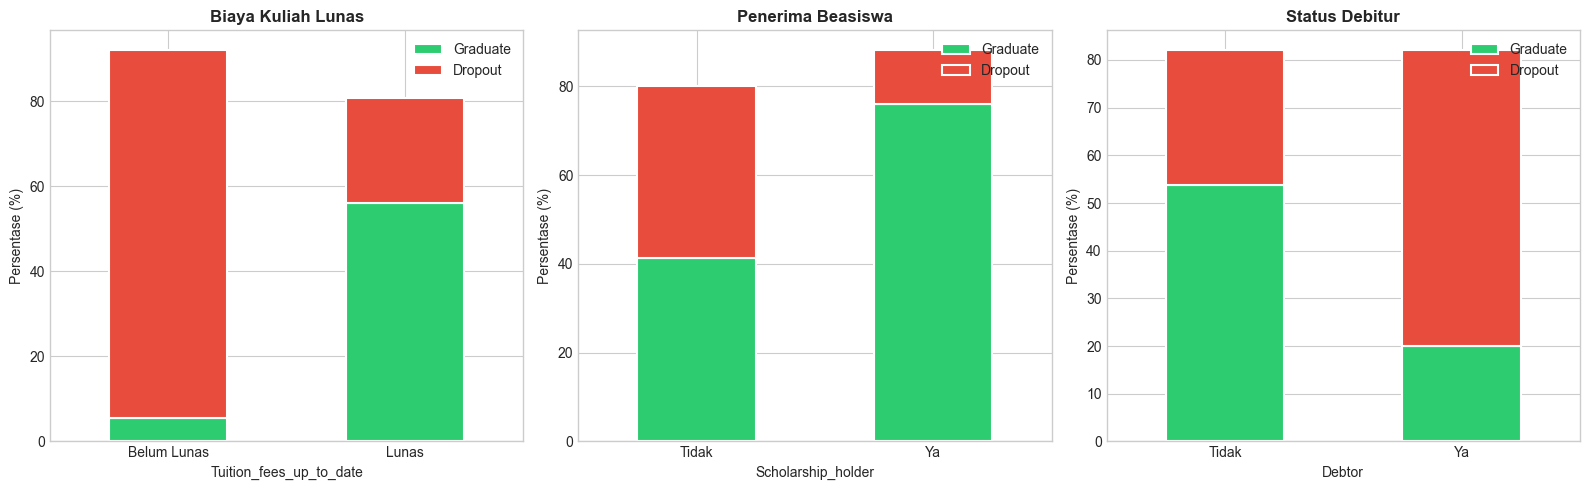

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

factors = [
    ('Tuition_fees_up_to_date', 'Biaya Kuliah Lunas', {0: 'Belum Lunas', 1: 'Lunas'}),
    ('Scholarship_holder', 'Penerima Beasiswa', {0: 'Tidak', 1: 'Ya'}),
    ('Debtor', 'Status Debitur', {0: 'Tidak', 1: 'Ya'})
]

for idx, (col, title, labels) in enumerate(factors):
    ct = pd.crosstab(df[col], df['Status'], normalize='index') * 100
    ct.index = ct.index.map(labels)
    ct[['Graduate', 'Dropout']].plot(
        kind='bar', stacked=True, ax=axes[idx],
        color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5
    )
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Persentase (%)')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    axes[idx].legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Distribusi Usia saat Pendaftaran berdasarkan Status


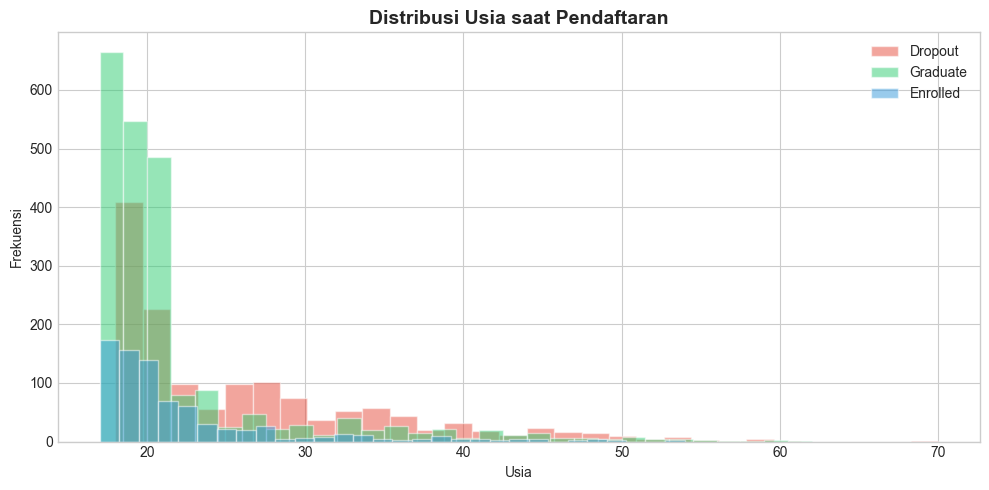

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for status, color in zip(['Dropout', 'Graduate', 'Enrolled'], ['#e74c3c', '#2ecc71', '#3498db']):
    subset = df[df['Status'] == status]
    ax.hist(subset['Age_at_enrollment'], bins=30, alpha=0.5, label=status, color=color, edgecolor='white')

ax.set_title('Distribusi Usia saat Pendaftaran', fontsize=14, fontweight='bold')
ax.set_xlabel('Usia')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

#### Dropout Rate per Program Studi


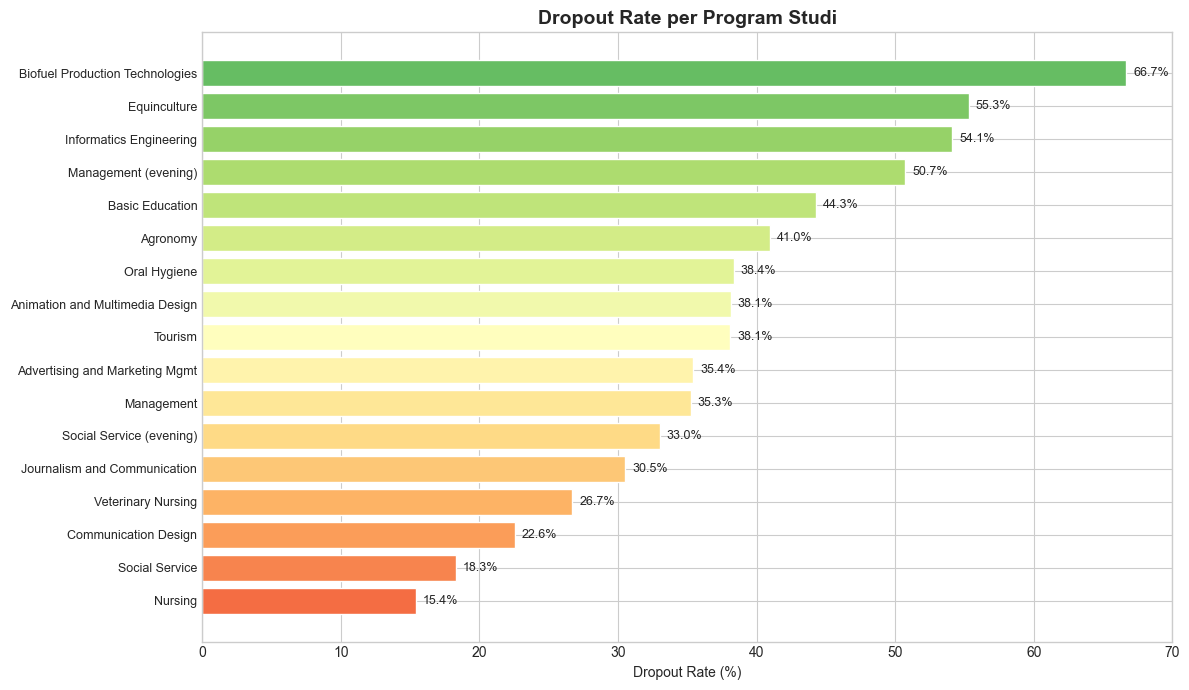

In [ ]:
course_map = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Mgmt',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening)'
}

df['Course_name'] = df['Course'].map(course_map)

dropout_rate = df.groupby('Course_name').apply(
    lambda x: (x['Status'] == 'Dropout').sum() / len(x) * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(dropout_rate)))
bars = ax.barh(range(len(dropout_rate)), dropout_rate.values, color=colors, edgecolor='white', linewidth=1)
ax.set_yticks(range(len(dropout_rate)))
ax.set_yticklabels(dropout_rate.index, fontsize=9)
ax.set_xlabel('Dropout Rate (%)')
ax.set_title('Dropout Rate per Program Studi', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, val in enumerate(dropout_rate.values):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### Dropout Rate berdasarkan Gender


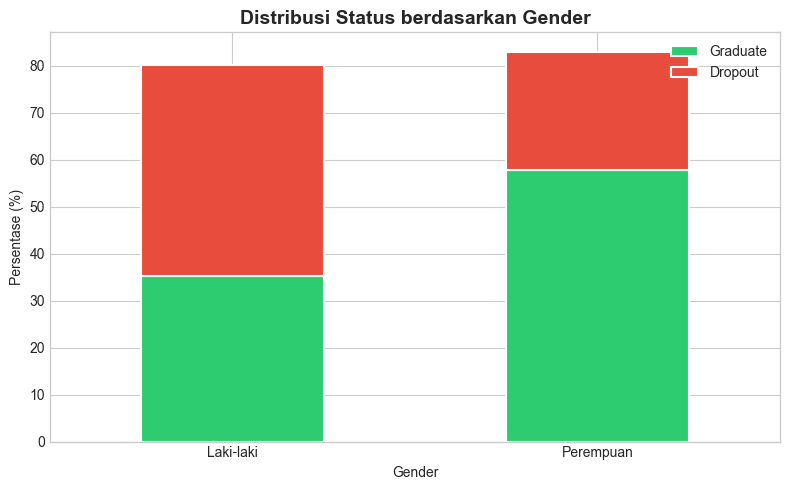

In [ ]:
gender_map = {0: 'Perempuan', 1: 'Laki-laki'}
gender_ct = pd.crosstab(df['Gender'].map(gender_map), df['Status'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
gender_ct[['Graduate', 'Dropout']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5
)
ax.set_title('Distribusi Status berdasarkan Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

#### Heatmap Korelasi Fitur Numerik Utama


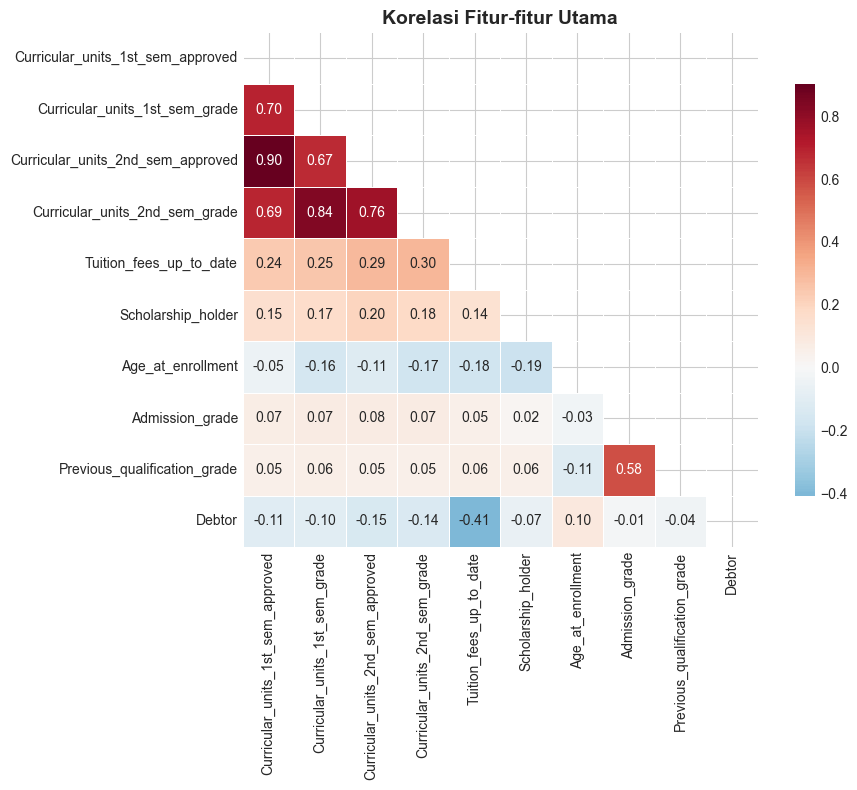

In [ ]:
key_features = [
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Tuition_fees_up_to_date', 'Scholarship_holder', 'Age_at_enrollment',
    'Admission_grade', 'Previous_qualification_grade', 'Debtor'
]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Korelasi Fitur-fitur Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preparation

Pada tahap ini dilakukan preprocessing data untuk mempersiapkan input model:
1. Filter data: hanya mengambil status Dropout dan Graduate (binary classification)
2. Label encoding pada target variable
3. Standardisasi fitur menggunakan StandardScaler
4. Split data ke train set (80%) dan test set (20%) dengan stratifikasi


In [ ]:
# Filter hanya Dropout dan Graduate
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f"Data setelah filter: {df_model.shape[0]} baris")
print(df_model['Status'].value_counts())

# Encode target
le = LabelEncoder()
df_model['Status_encoded'] = le.fit_transform(df_model['Status'])
print(f"\nMapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Definisikan fitur
feature_cols = [c for c in df_model.columns if c not in ['Status', 'Status_encoded', 'Course_name']]
X = df_model[feature_cols]
y = df_model['Status_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} baris")
print(f"Test set: {X_test.shape[0]} baris")

# Standarisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nJumlah fitur: {len(feature_cols)}")

Data setelah filter: 3630 baris
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Mapping: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}

Train set: 2904 baris
Test set: 726 baris

Jumlah fitur: 36


## Modeling

Model yang digunakan adalah Random Forest Classifier dengan konfigurasi:
- 200 estimators (decision trees)
- Max depth 15 untuk mencegah overfitting
- Min samples split 5 dan min samples leaf 2
- Random state 42 untuk reproducibility


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)

## Evaluation


### Classification Report


In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba[:, 1]):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9105
ROC-AUC: 0.9542

              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.88       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



### Confusion Matrix


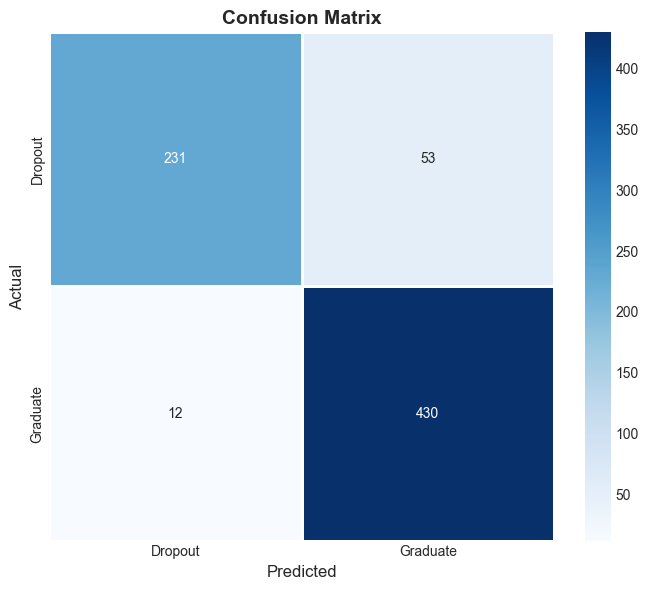

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='white')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve


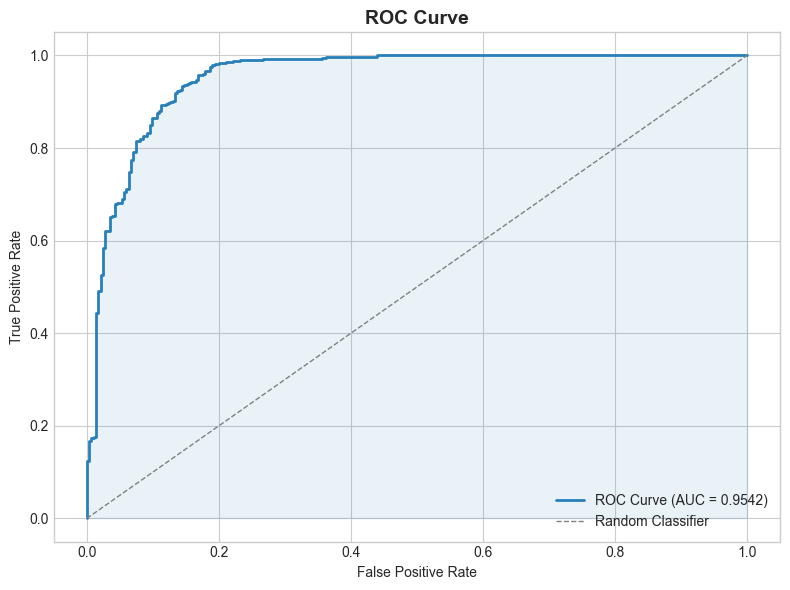

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
auc_score = roc_auc_score(y_test, y_proba[:, 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Feature Importance


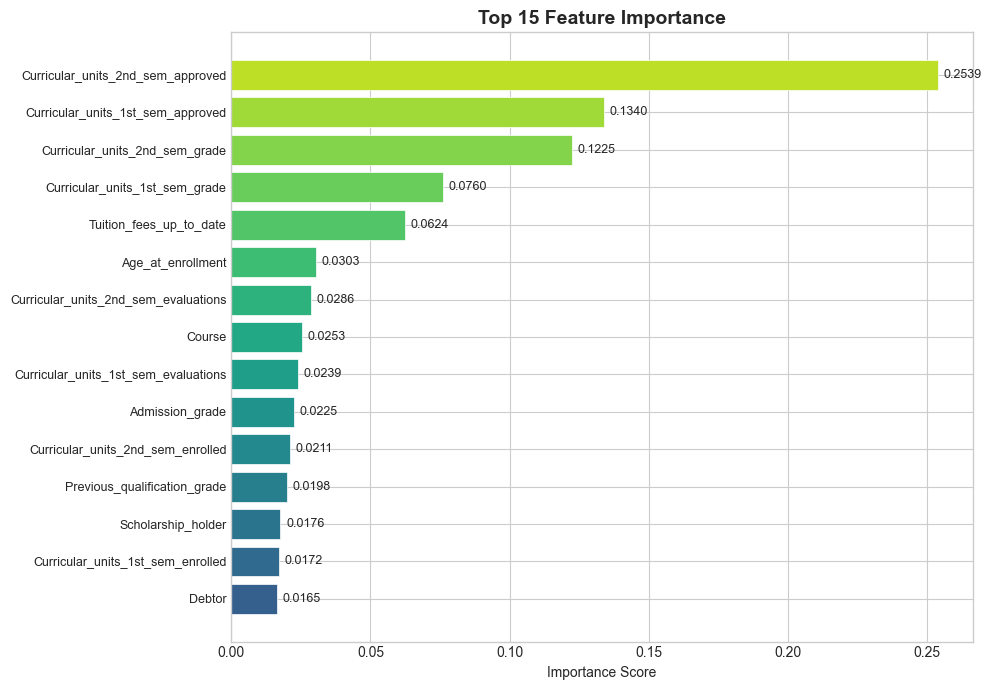

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
top_15 = importances.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15)))
ax.barh(range(len(top_15)), top_15.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15.index, fontsize=9)
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importance', fontsize=14, fontweight='bold')

for i, val in enumerate(top_15.values):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Insight dari Evaluasi Model

Model Random Forest menghasilkan performa yang baik:
- **Accuracy: 91.05%** - secara keseluruhan model mampu mengklasifikasikan dengan benar 91% data test
- **ROC-AUC: 0.9542** - menunjukkan kemampuan diskriminasi yang sangat baik
- **Recall Dropout: 81%** - model berhasil mendeteksi 81% mahasiswa dropout
- **Precision Dropout: 95%** - dari prediksi dropout, 95% benar-benar dropout

Faktor paling berpengaruh terhadap dropout:
1. Jumlah mata kuliah yang disetujui di semester 2
2. Jumlah mata kuliah yang disetujui di semester 1
3. Nilai rata-rata semester 2
4. Nilai rata-rata semester 1
5. Status pembayaran biaya kuliah


## Menyimpan Model dan Artefak


In [ ]:
import os
os.makedirs('model', exist_ok=True)

joblib.dump(rf, 'model/model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(feature_cols, 'model/features.joblib')
joblib.dump(le, 'model/label_encoder.joblib')

print("Artefak tersimpan:")
for f in os.listdir('model'):
    size = os.path.getsize(os.path.join('model', f))
    print(f"  {f} ({size:,} bytes)")

Artefak tersimpan:
  contoh.joblib (0 bytes)
  scaler.joblib (2,599 bytes)
  model.joblib (6,268,329 bytes)
  label_encoder.joblib (494 bytes)
  features.joblib (926 bytes)
